In [1]:
# Install dependencies
!pip install ultralytics roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.8/89.8 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 67.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 129.5 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10


In [2]:
# Import necessary libraries
import ultralytics
from ultralytics import YOLO
from roboflow import Roboflow
import os
import torch

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
# Check if GPU is available
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cuda


In [4]:
# Download dataset from Roboflow
rf = Roboflow(api_key="Npr82rgYiQ5A5trJBlb8")
project = rf.workspace("capstone2025-mifho").project("military-base-object-detection")
version = project.version(15)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Military-Base-Object-Detection-15 in yolov8:: 100%|██████████| 24198/24198 [00:10<00:00, 2398.35it/s]


In [5]:
# Get dataset directory
dataset_path = dataset.location

In [6]:
# Define YOLOv8 model (pretrained on COCO, transfer learning to your dataset)
model = YOLO("yolov8n.pt").to(device)  # Move model to GPU if available

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
# Adjust batch size for CPU if necessary
batch_size = 8 if device == 'cuda' else 2  # Reduce batch size for CPU

In [10]:
results = model.train(
    data=os.path.join(dataset_path, "data.yaml"),
    epochs=12,               # ⬅️ Increase to 100
    batch=batch_size,
    imgsz=640,
    device=device,
    patience=15,              # ⬅️ Early stopping if desired
    verbose=False
)
model.val()
model.plot_results()  # Creates results.png in the same folder


Ultralytics 8.3.204 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Military-Base-Object-Detection-15/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=12, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=15, perspective=0.0

AttributeError: 'DetectionModel' object has no attribute 'plot_results'

In [11]:
!cp runs/detect/train/weights/best.pt /content/drive/MyDrive/
!cp runs/detect/train/weights/last.pt /content/drive/MyDrive/


cp: cannot stat 'runs/detect/train/weights/best.pt': No such file or directory
cp: cannot stat 'runs/detect/train/weights/last.pt': No such file or directory


In [12]:
from ultralytics import YOLO

# Load the best trained model
model = YOLO("runs/detect/train2/weights/best.pt")

# Export to ONNX
model.export(format="onnx", dynamic=True, simplify=True)
!cp runs/detect/train/weights/best.onnx /content/drive/MyDrive/

Ultralytics 8.3.204 🚀 Python-3.12.11 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 72 layers, 3,008,183 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from 'runs/detect/train2/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 17, 8400) (5.9 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0', 'onnxslim>=0.1.67', 'onnxruntime-gpu'] not found, attempting AutoUpdate...

requirements: AutoUpdate success ✅ 6.1s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.19.1rc1 opset 22...
ONNX: slimming with onnxslim 0.1.70...
ONNX: export success ✅ 9.1s, saved as 'runs/detect/train2/weights/best.onnx' (11.7 MB)

Export complete (9.6s)
Results saved to /content/runs/detect/train2/weights
Predict:         yolo predict tas

In [13]:
!grep -r "22 " /content/datasets/coco/labels/


grep: /content/datasets/coco/labels/: No such file or directory


In [14]:

# Evaluate the model
metrics = model.val()
print("Validation Metrics:", metrics)

Ultralytics 8.3.204 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,008,183 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1254.0±764.1 MB/s, size: 101.5 KB)
val: Scanning /content/Military-Base-Object-Detection-15/valid/labels.cache... 1911 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1911/1911 3.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 120/120 5.6it/s 21.3s
                   all       1911       4287      0.661      0.549      0.613      0.392
              Aircraft        127        408      0.788      0.655      0.705      0.288
            Camouflage        232        297      0.794      0.704      0.793      0.457
                 Drone         73         73       0.67      0.863      0.862       0.55
                  Fire         82        168      0.451      0.162      0.211     0.0748
               Gr

In [15]:

CLASSES = ['Aircraft', 'Camouflage', 'Drone', 'Fire', 'Grenade','Hand-Gun', 'Knife', 'Military-Vehicle', 'Missile', 'Pistol', 'Rifle', 'Smoke', 'Soldier']

In [16]:
# Run inference on the test dataset
test_results = model.val(data=os.path.join(dataset_path, "data.yaml"), split='test')

# Print test metrics
print("Test Results:", test_results)


Ultralytics 8.3.204 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 9.2±8.8 MB/s, size: 36.9 KB)
val: Scanning /content/Military-Base-Object-Detection-15/test/labels... 1767 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1767/1767 677.0it/s 2.6s
val: New cache created: /content/Military-Base-Object-Detection-15/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 111/111 5.4it/s 20.4s
                   all       1767       4130      0.618      0.537      0.584      0.352
              Aircraft        126        360      0.717      0.746      0.779      0.355
            Camouflage        230        293      0.728      0.686      0.741      0.363
                 Drone         70         79      0.504      0.532      0.516      0.286
                  Fire        110        269      0.613      0.236      0.388      0.143
               Grenade  

In [17]:
# Run inference on the test dataset
import time

start_time = time.time()
test_results = model.val(data=os.path.join(dataset_path, "data.yaml"), split='test')
end_time = time.time()

# Compute average inference time per image
num_images = 154  # Total test images
total_inference_time = end_time - start_time
avg_inference_time = total_inference_time / num_images if num_images > 0 else 0
fps = 1 / avg_inference_time if avg_inference_time > 0 else 0

# Print Results
print(f"Test Dataset Size: {num_images} images")
print(f"Total Inference Time: {total_inference_time:.4f} sec")
print(f"Average Inference Time per Image: {avg_inference_time:.4f} sec")
print(f"Inference Speed: {fps:.2f} FPS")

# Compute number of parameters
num_params = sum(p.numel() for p in model.model.parameters())
print(f"Total Parameters in YOLOv8 Model: {num_params:,}")

# Print test metrics
print("Test Results:", test_results)


Ultralytics 8.3.204 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2271.8±820.7 MB/s, size: 262.4 KB)
val: Scanning /content/Military-Base-Object-Detection-15/test/labels.cache... 1767 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1767/1767 2.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 111/111 6.0it/s 18.6s
                   all       1767       4130      0.618      0.537      0.584      0.352
              Aircraft        126        360      0.717      0.746      0.779      0.355
            Camouflage        230        293      0.728      0.686      0.741      0.363
                 Drone         70         79      0.504      0.532      0.516      0.286
                  Fire        110        269      0.613      0.236      0.388      0.143
               Grenade        222        365      0.579      0.677       0.68      0.479
         

In [18]:
# Extract and print mAP metrics
print(f"mAP@50: {test_results.box.map50:.2f}")
print(f"mAP@75: {test_results.box.map75:.2f}")

mAP@50: 0.58
mAP@75: 0.35


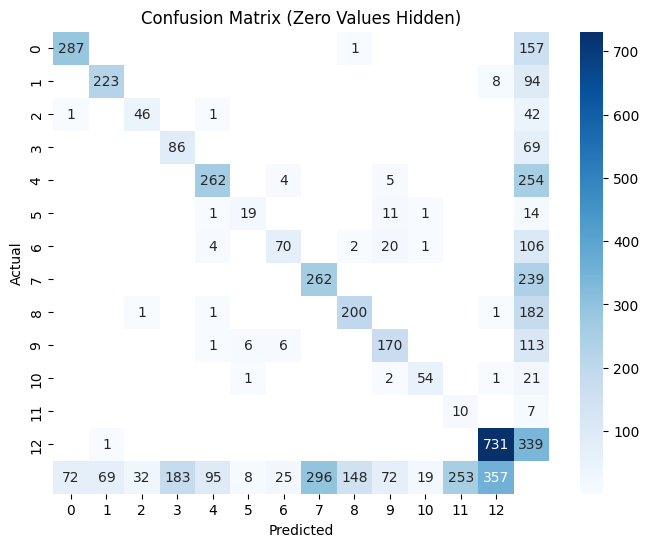

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Extract the confusion matrix
cm = test_results.confusion_matrix.matrix

# Ensure cm is a NumPy array
cm = np.array(cm)

# Create a mask to hide zero values
mask = cm == 0

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=".0f", cmap="Blues", xticklabels=test_results.names,
            yticklabels=test_results.names, mask=mask, linewidths=0, linecolor='gray')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Zero Values Hidden)")
plt.show()


In [20]:
import numpy as np
import pandas as pd

# Extract the confusion matrix
cm = test_results.confusion_matrix.matrix

# Ensure cm is a NumPy array
cm = np.array(cm)

# Compute per-class accuracy
class_accuracy = np.diag(cm) / cm.sum(axis=1)  # True Positives / Total Samples in Class

# Store results in a dictionary
accuracy_results = {
    test_results.names[i]: f"{class_accuracy[i] * 100:.2f}" if not np.isnan(class_accuracy[i]) else "0.00"
    for i in range(len(test_results.names))
}

# Convert to DataFrame for better readability
accuracy_df = pd.DataFrame(list(accuracy_results.items()), columns=["Class", "Accuracy (%)"])

# Calculate average accuracy
avg_accuracy = accuracy_df["Accuracy (%)"].astype(float).mean()

# Display accuracy table
print(accuracy_df)
print(f"\n\033[1mAverage Accuracy: {avg_accuracy:.2f}%\033[0m")


               Class Accuracy (%)
0           Aircraft        64.49
1         Camouflage        68.62
2              Drone        51.11
3               Fire        55.48
4            Grenade        49.90
5           Hand-Gun        41.30
6              Knife        34.48
7   Military-Vehicle        52.30
8            Missile        51.95
9             Pistol        57.43
10             Rifle        68.35
11             Smoke        58.82
12           Soldier        68.25

Average Accuracy: 55.58%
